# Student Performance Analysis Using Data Science

## Mathematics for Data Science and Analytics (MDSA)

### Team Members

- Dola Mounika
- Sejal Heda
- Bhavya Potnuru

### Academic Year

2025–2026

## Abstract

This project analyzes student academic performance using Mathematics and Portuguese student datasets obtained from the UCI Machine Learning Repository. The project applies data preprocessing, statistical analysis, exploratory data analysis, correlation analysis, and predictive modeling techniques to identify factors affecting student performance. The findings provide insights into academic trends and support data-driven educational decision-making.

## Introduction

- Educational institutions generate large amounts of student data.
- Analyzing this data helps understand factors influencing academic performance.
- Data science techniques can uncover patterns and trends in student achievement.
- This project explores student performance using Mathematics and Portuguese datasets.

## Problem Statement

Student performance is influenced by several academic, social, and personal factors. This project aims to identify these factors and analyze their impact on students' final grades using data science techniques.

## Objectives

- Analyze student performance data.
- Identify factors affecting final grades.
- Compare Mathematics and Portuguese student performance.
- Perform correlation analysis on key attributes.
- Build a predictive model for grade prediction.

## Dataset Description

### Datasets Used

1. Mathematics Student Performance Dataset
2. Portuguese Student Performance Dataset

### Important Attributes

- age
- studytime
- failures
- absences
- G1 (First Period Grade)
- G2 (Second Period Grade)
- G3 (Final Grade)

Both datasets contain demographic, social, and academic information related to student performance.

## Data Understanding

This section loads the datasets and examines their structure, dimensions, and data types.

### Import Libraries

The required libraries for data analysis, visualization, and machine learning are imported.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

### Load Datasets

The Mathematics and Portuguese student datasets are loaded into DataFrames.

In [2]:
df_math = pd.read_csv("student-mat.csv", sep=';')
df_por = pd.read_csv("student-por.csv", sep=';')

### Dataset Dimensions

The shape of each dataset is checked to determine the number of rows and columns.

In [3]:
print("Mathematics Dataset Shape:", df_math.shape)
print("Portuguese Dataset Shape:", df_por.shape)

Mathematics Dataset Shape: (395, 33)
Portuguese Dataset Shape: (649, 33)


### Dataset Preview

The first few records are displayed to understand the dataset structure.

In [4]:
df_math.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [5]:
df_por.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


### Dataset Information

Information about columns, data types, and non-null values is displayed.

In [6]:
df_math.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

In [7]:
df_por.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      649 non-null    object
 1   sex         649 non-null    object
 2   age         649 non-null    int64 
 3   address     649 non-null    object
 4   famsize     649 non-null    object
 5   Pstatus     649 non-null    object
 6   Medu        649 non-null    int64 
 7   Fedu        649 non-null    int64 
 8   Mjob        649 non-null    object
 9   Fjob        649 non-null    object
 10  reason      649 non-null    object
 11  guardian    649 non-null    object
 12  traveltime  649 non-null    int64 
 13  studytime   649 non-null    int64 
 14  failures    649 non-null    int64 
 15  schoolsup   649 non-null    object
 16  famsup      649 non-null    object
 17  paid        649 non-null    object
 18  activities  649 non-null    object
 19  nursery     649 non-null    object
 20  higher    

### Column Names

The column names present in both datasets are displayed.

In [8]:
print("Mathematics Dataset Columns:")
print(df_math.columns)

print("\nPortuguese Dataset Columns:")
print(df_por.columns)

Mathematics Dataset Columns:
Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='object')

Portuguese Dataset Columns:
Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='object')


**Observation:** 
- Both datasets contain similar attributes.
- Each dataset contains academic, demographic, and social information.
- The datasets are suitable for comparative and predictive analysis.

# Data Preprocessing
- Missing Value Analysis
- Missing Value Treatment
- Duplicate Value Analysis
- Duplicate Value Removal
- Observation

### Missing Value Analysis

This step checks whether any missing values are present in the datasets.

In [9]:
df_math.isnull().sum()


school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

In [10]:
df_por.isnull().sum()

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

### Verify Missing Values

After treatment, the datasets are checked again to ensure that no missing values remain.

In [11]:
df_math.isnull().sum()

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

In [12]:
df_por.isnull().sum()

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

### Duplicate Value Analysis

This step checks for duplicate records in both datasets.

In [13]:
df_math.duplicated().sum()

np.int64(0)

In [14]:
df_por.duplicated().sum()

np.int64(0)

### Verify Dataset Shape

The dataset dimensions are checked after removing duplicate records.

In [15]:
print("Mathematics Dataset Shape:", df_math.shape)
print("Portuguese Dataset Shape:", df_por.shape)

Mathematics Dataset Shape: (395, 33)
Portuguese Dataset Shape: (649, 33)


**Observation:** 
- Both datasets contain a sufficient number of records for analysis.
- The Mathematics and Portuguese datasets have similar structures.
- The datasets are clean and ready for statistical analysis and visualization.

## Descriptive Statistical Analysis

Descriptive statistics are used to summarize and understand the numerical characteristics of the datasets.

### Mathematics Dataset Statistics

The summary statistics for the Mathematics dataset are displayed below.

In [16]:
df_math.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


### Portuguese Dataset Statistics

The summary statistics for the Portuguese dataset are displayed below.

In [17]:
df_por.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000
mean,16.744222,2.514638,2.306626,1.568567,1.930663,0.221880,3.930663,3.180277,3.184900,1.502311,2.280431,3.536210,3.659476,11.399076,11.570108,11.906009
std,1.218138,1.134552,1.099931,0.748660,0.829510,0.593235,0.955717,1.051093,1.175766,0.924834,1.284380,1.446259,4.640759,2.745265,2.913639,3.230656
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,16.000000,2.000000,1.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,2.000000,0.000000,10.000000,10.000000,10.000000
50%,17.000000,2.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,2.000000,11.000000,11.000000,12.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,6.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,32.000000,19.000000,19.000000,19.000000


### Mean Analysis

The mean provides the average value of each numerical attribute.

In [18]:
df_math.mean(numeric_only=True)

age           16.696203
Medu           2.749367
Fedu           2.521519
traveltime     1.448101
studytime      2.035443
failures       0.334177
famrel         3.944304
freetime       3.235443
goout          3.108861
Dalc           1.481013
Walc           2.291139
health         3.554430
absences       5.708861
G1            10.908861
G2            10.713924
G3            10.415190
dtype: float64

In [19]:
df_por.mean(numeric_only=True)

age           16.744222
Medu           2.514638
Fedu           2.306626
traveltime     1.568567
studytime      1.930663
failures       0.221880
famrel         3.930663
freetime       3.180277
goout          3.184900
Dalc           1.502311
Walc           2.280431
health         3.536210
absences       3.659476
G1            11.399076
G2            11.570108
G3            11.906009
dtype: float64

### Median Analysis

The median represents the middle value of each numerical attribute.

In [20]:
df_math.median(numeric_only=True)

age           17.0
Medu           3.0
Fedu           2.0
traveltime     1.0
studytime      2.0
failures       0.0
famrel         4.0
freetime       3.0
goout          3.0
Dalc           1.0
Walc           2.0
health         4.0
absences       4.0
G1            11.0
G2            11.0
G3            11.0
dtype: float64

In [21]:
df_por.median(numeric_only=True)

age           17.0
Medu           2.0
Fedu           2.0
traveltime     1.0
studytime      2.0
failures       0.0
famrel         4.0
freetime       3.0
goout          3.0
Dalc           1.0
Walc           2.0
health         4.0
absences       2.0
G1            11.0
G2            11.0
G3            12.0
dtype: float64

### Standard Deviation Analysis

Standard deviation measures the spread of values from the mean.

In [22]:
df_math.std(numeric_only=True)

age           1.276043
Medu          1.094735
Fedu          1.088201
traveltime    0.697505
studytime     0.839240
failures      0.743651
famrel        0.896659
freetime      0.998862
goout         1.113278
Dalc          0.890741
Walc          1.287897
health        1.390303
absences      8.003096
G1            3.319195
G2            3.761505
G3            4.581443
dtype: float64

In [23]:
df_por.std(numeric_only=True)

age           1.218138
Medu          1.134552
Fedu          1.099931
traveltime    0.748660
studytime     0.829510
failures      0.593235
famrel        0.955717
freetime      1.051093
goout         1.175766
Dalc          0.924834
Walc          1.284380
health        1.446259
absences      4.640759
G1            2.745265
G2            2.913639
G3            3.230656
dtype: float64

### Variance Analysis

Variance indicates how far data points are spread from the mean.

In [24]:
df_math.var(numeric_only=True)

age            1.628285
Medu           1.198445
Fedu           1.184180
traveltime     0.486513
studytime      0.704324
failures       0.553017
famrel         0.803997
freetime       0.997725
goout          1.239388
Dalc           0.793420
Walc           1.658678
health         1.932944
absences      64.049541
G1            11.017053
G2            14.148917
G3            20.989616
dtype: float64

In [25]:
df_por.var(numeric_only=True)

age            1.483859
Medu           1.287208
Fedu           1.209848
traveltime     0.560492
studytime      0.688086
failures       0.351928
famrel         0.913395
freetime       1.104796
goout          1.382426
Dalc           0.855319
Walc           1.649632
health         2.091665
absences      21.536642
G1             7.536481
G2             8.489290
G3            10.437140
dtype: float64

**Observation:** 
- The average student age is around 16–17 years.
- Most students have low failure rates.
- Final grades show moderate variation across students.
- Absences exhibit higher variability compared to other attributes.

## Exploratory Data Analysis (EDA)

EDA helps visualize patterns, trends, and relationships within the datasets.

### Distribution of Final Grades (G3)

This visualization shows the distribution of final grades in the Mathematics dataset.

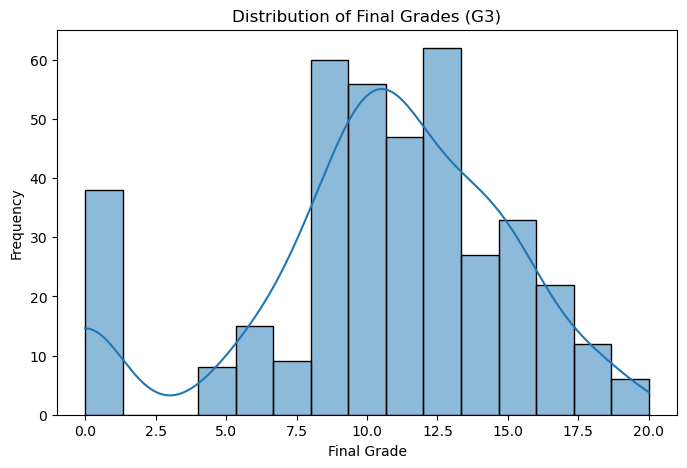

In [26]:
plt.figure(figsize=(8,5))
sns.histplot(df_math['G3'], bins=15, kde=True)

plt.title("Distribution of Final Grades (G3)")
plt.xlabel("Final Grade")
plt.ylabel("Frequency")

plt.show()

**Observation:** Most students scored in the middle grade range, with fewer students achieving extremely low or high grades.

## Correlation Analysis

Correlation analysis helps identify relationships between numerical variables and their influence on student performance.

### Correlation Matrix - Mathematics Dataset

In [27]:
corr_math = df_math.select_dtypes(include='number').corr()
corr_math

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
age,1.000000,-0.163658,-0.163438,0.070641,-0.004140,0.243665,0.053940,0.016434,0.126964,0.131125,0.117276,-0.062187,0.175230,-0.064081,-0.143474,-0.161579
Medu,-0.163658,1.000000,0.623455,-0.171639,0.064944,-0.236680,-0.003914,0.030891,0.064094,0.019834,-0.047123,-0.046878,0.100285,0.205341,0.215527,0.217147
Fedu,-0.163438,0.623455,1.000000,-0.158194,-0.009175,-0.250408,-0.001370,-0.012846,0.043105,0.002386,-0.012631,0.014742,0.024473,0.190270,0.164893,0.152457
traveltime,0.070641,-0.171639,-0.158194,1.000000,-0.100909,0.092239,-0.016808,-0.017025,0.028540,0.138325,0.134116,0.007501,-0.012944,-0.093040,-0.153198,-0.117142
studytime,-0.004140,0.064944,-0.009175,-0.100909,1.000000,-0.173563,0.039731,-0.143198,-0.063904,-0.196019,-0.253785,-0.075616,-0.062700,0.160612,0.135880,0.097820
failures,0.243665,-0.236680,-0.250408,0.092239,-0.173563,1.000000,-0.044337,0.091987,0.124561,0.136047,0.141962,0.065827,0.063726,-0.354718,-0.355896,-0.360415
famrel,0.053940,-0.003914,-0.001370,-0.016808,0.039731,-0.044337,1.000000,0.150701,0.064568,-0.077594,-0.113397,0.094056,-0.044354,0.022168,-0.018281,0.051363
freetime,0.016434,0.030891,-0.012846,-0.017025,-0.143198,0.091987,0.150701,1.000000,0.285019,0.209001,0.147822,0.075733,-0.058078,0.012613,-0.013777,0.011307
goout,0.126964,0.064094,0.043105,0.028540,-0.063904,0.124561,0.064568,0.285019,1.000000,0.266994,0.420386,-0.009577,0.044302,-0.149104,-0.162250,-0.132791
Dalc,0.131125,0.019834,0.002386,0.138325,-0.196019,0.136047,-0.077594,0.209001,0.266994,1.000000,0.647544,0.077180,0.111908,-0.094159,-0.064120,-0.054660


### Correlation Heatmap - Mathematics Dataset

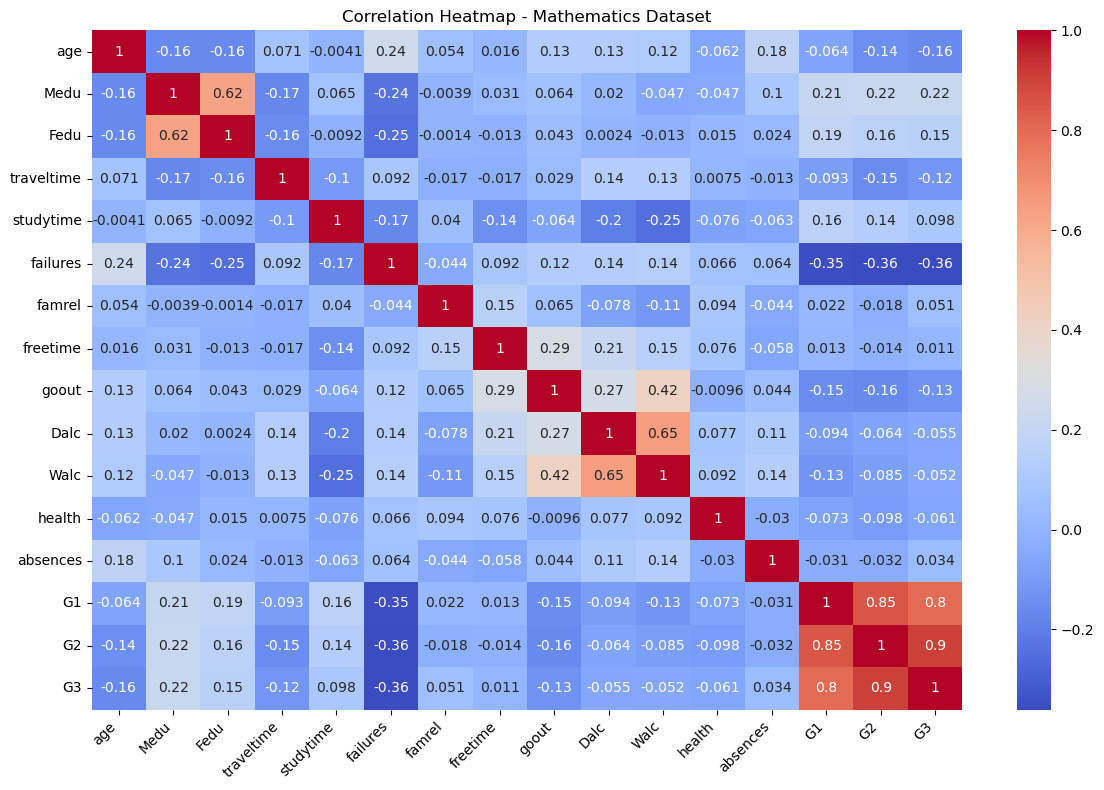

In [28]:
plt.figure(figsize=(12,8))

sns.heatmap(corr_math, annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap - Mathematics Dataset")

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

### Correlation Matrix - Portuguese Dataset

In [29]:
corr_por = df_por.select_dtypes(include='number').corr()
corr_por

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
age,1.000000,-0.107832,-0.121050,0.034490,-0.008415,0.319968,-0.020559,-0.004910,0.112805,0.134768,0.086357,-0.008750,0.149998,-0.174322,-0.107119,-0.106505
Medu,-0.107832,1.000000,0.647477,-0.265079,0.097006,-0.172210,0.024421,-0.019686,0.009536,-0.007018,-0.019766,0.004614,-0.008577,0.260472,0.264035,0.240151
Fedu,-0.121050,0.647477,1.000000,-0.208288,0.050400,-0.165915,0.020256,0.006841,0.027690,0.000061,0.038445,0.044910,0.029859,0.217501,0.225139,0.211800
traveltime,0.034490,-0.265079,-0.208288,1.000000,-0.063154,0.097730,-0.009521,0.000937,0.057454,0.092824,0.057007,-0.048261,-0.008149,-0.154120,-0.154489,-0.127173
studytime,-0.008415,0.097006,0.050400,-0.063154,1.000000,-0.147441,-0.004127,-0.068829,-0.075442,-0.137585,-0.214925,-0.056433,-0.118389,0.260875,0.240498,0.249789
failures,0.319968,-0.172210,-0.165915,0.097730,-0.147441,1.000000,-0.062645,0.108995,0.045078,0.105949,0.082266,0.035588,0.122779,-0.384210,-0.385782,-0.393316
famrel,-0.020559,0.024421,0.020256,-0.009521,-0.004127,-0.062645,1.000000,0.129216,0.089707,-0.075767,-0.093511,0.109559,-0.089534,0.048795,0.089588,0.063361
freetime,-0.004910,-0.019686,0.006841,0.000937,-0.068829,0.108995,0.129216,1.000000,0.346352,0.109904,0.120244,0.084526,-0.018716,-0.094497,-0.106678,-0.122705
goout,0.112805,0.009536,0.027690,0.057454,-0.075442,0.045078,0.089707,0.346352,1.000000,0.245126,0.388680,-0.015741,0.085374,-0.074053,-0.079469,-0.087641
Dalc,0.134768,-0.007018,0.000061,0.092824,-0.137585,0.105949,-0.075767,0.109904,0.245126,1.000000,0.616561,0.059067,0.172952,-0.195171,-0.189480,-0.204719


### Correlation Heatmap - Portuguese Dataset

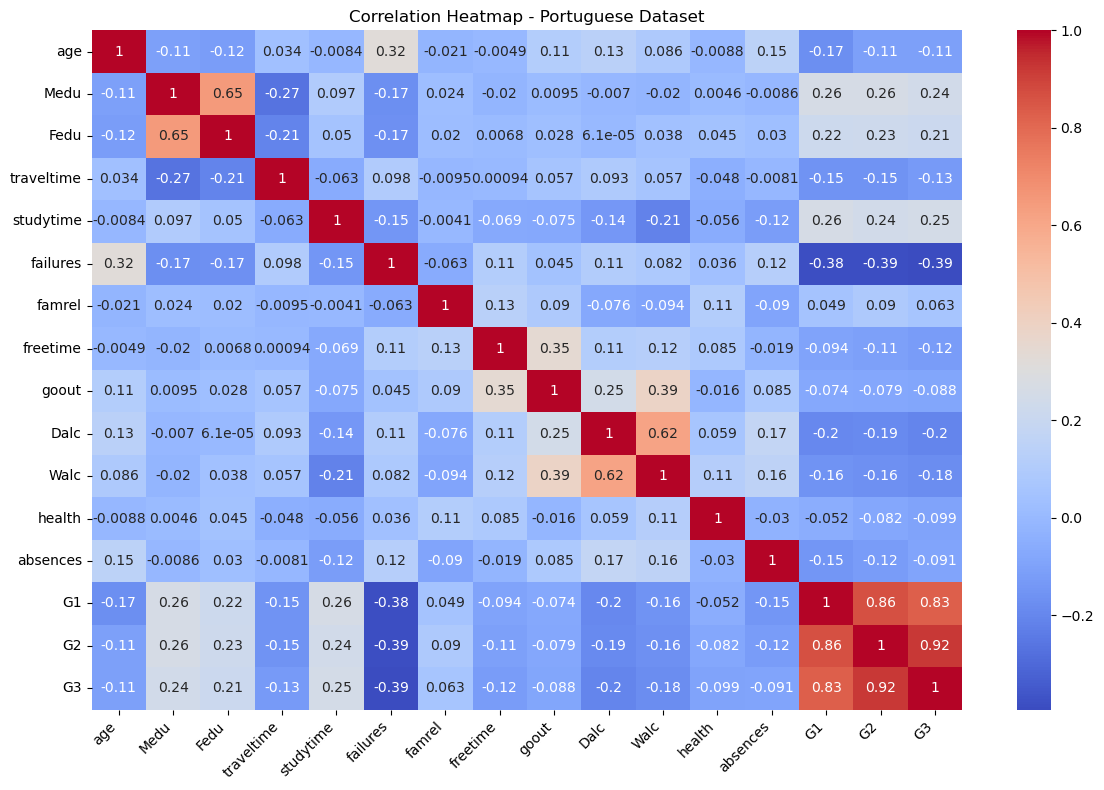

In [30]:
plt.figure(figsize=(12,8))

sns.heatmap(corr_por, annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap - Portuguese Dataset")

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

### Factors Influencing Final Grade (G3)

In [31]:
print("Mathematics Dataset")
print(corr_math["G3"].sort_values(ascending=False))

print("\nPortuguese Dataset")
print(corr_por["G3"].sort_values(ascending=False))

Mathematics Dataset
G3            1.000000
G2            0.904868
G1            0.801468
Medu          0.217147
Fedu          0.152457
studytime     0.097820
famrel        0.051363
absences      0.034247
freetime      0.011307
Walc         -0.051939
Dalc         -0.054660
health       -0.061335
traveltime   -0.117142
goout        -0.132791
age          -0.161579
failures     -0.360415
Name: G3, dtype: float64

Portuguese Dataset
G3            1.000000
G2            0.918548
G1            0.826387
studytime     0.249789
Medu          0.240151
Fedu          0.211800
famrel        0.063361
goout        -0.087641
absences     -0.091379
health       -0.098851
age          -0.106505
freetime     -0.122705
traveltime   -0.127173
Walc         -0.176619
Dalc         -0.204719
failures     -0.393316
Name: G3, dtype: float64


**Observation:** 
- G1 and G2 show the strongest positive correlation with G3.
- Failures have a negative correlation with final grades.
- Study time shows a positive relationship with academic performance.
- Previous academic performance is the strongest predictor of final grades.

## Comparative Analysis

This section compares the performance characteristics of students in the Mathematics and Portuguese datasets.

### Average Final Grade Comparison

The average final grade (G3) is compared between the two datasets.

In [32]:
comparison = pd.DataFrame({
    'Dataset': ['Mathematics', 'Portuguese'],
    'Average_G3': [
        df_math['G3'].mean(),
        df_por['G3'].mean()
    ]
})

comparison

,Dataset,Average_G3
0,Mathematics,10.415190
1,Portuguese,11.906009


### Visualization of Average Final Grades

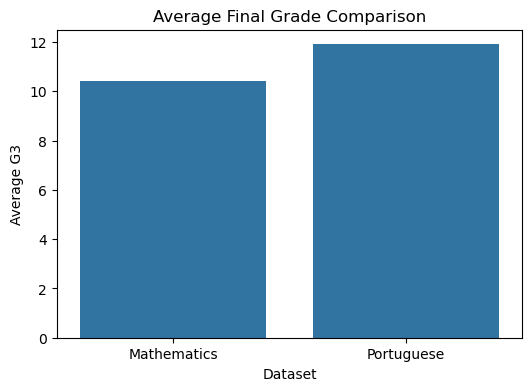

In [33]:
plt.figure(figsize=(6,4))

sns.barplot(
    data=comparison,
    x='Dataset',
    y='Average_G3'
)

plt.title("Average Final Grade Comparison")
plt.xlabel("Dataset")
plt.ylabel("Average G3")

plt.show()

**Observation:** 
The average final grades differ between the Mathematics and Portuguese datasets, indicating variation in student performance across subjects.

### Average Study Time Comparison

In [34]:
study_comparison = pd.DataFrame({
    'Dataset': ['Mathematics', 'Portuguese'],
    'Average_StudyTime': [
        df_math['studytime'].mean(),
        df_por['studytime'].mean()
    ]
})

study_comparison

,Dataset,Average_StudyTime
0,Mathematics,2.035443
1,Portuguese,1.930663


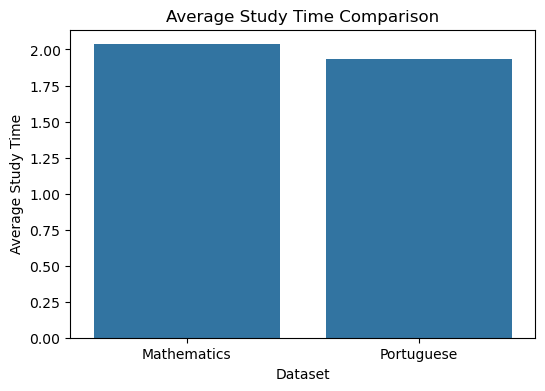

In [35]:
plt.figure(figsize=(6,4))

sns.barplot(
    data=study_comparison,
    x='Dataset',
    y='Average_StudyTime'
)

plt.title("Average Study Time Comparison")
plt.xlabel("Dataset")
plt.ylabel("Average Study Time")

plt.show()

**Observation:** Study time varies slightly between the two groups of students and may influence academic performance.

## Predictive Modeling

Predictive modeling is used to estimate a student's final grade (G3) based on academic and behavioral factors. A Multiple Linear Regression model is employed to analyze the relationship between multiple independent variables and the target variable.

### Feature Selection

The following attributes are selected as predictor variables for the model.

In [36]:
features = ['age', 'studytime', 'failures', 'absences', 'G1', 'G2']

X = df_math[features]
y = df_math['G3']

### Observation

The selected features represent student demographics, study habits, academic history, and previous grades that may influence final performance.

### Train-Test Split

The dataset is divided into training and testing sets to evaluate model performance.

In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

**Observation:** Eighty percent of the data is used for training, while twenty percent is reserved for testing.

### Multiple Linear Regression Model

A Multiple Linear Regression model is trained using the selected predictor variables.

In [38]:
model = LinearRegression()

model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


**Observation:** The model learns the relationship between the selected features and the final grade (G3).

### Model Predictions

The trained model is used to predict final grades for the test dataset.

In [39]:
y_pred = model.predict(X_test)

### Actual vs Predicted Grades

A scatter plot is used to compare actual grades with predicted grades.

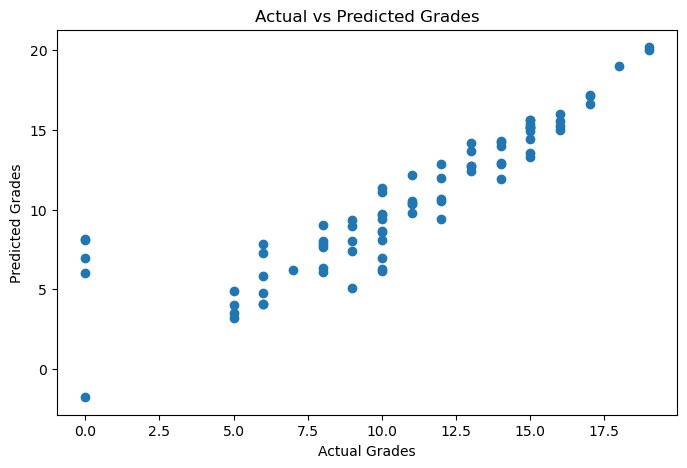

In [40]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred)

plt.title("Actual vs Predicted Grades")
plt.xlabel("Actual Grades")
plt.ylabel("Predicted Grades")

plt.show()

**Observation:** Predicted grades generally follow the trend of actual grades, indicating that the model captures important patterns in the data.

### Model Evaluation

The performance of the model is evaluated using MAE, RMSE, and R² Score.

In [41]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", round(mae,2))
print("Root Mean Squared Error (RMSE):", round(rmse,2))
print("R² Score:", round(r2,2))

Mean Absolute Error (MAE): 1.33
Root Mean Squared Error (RMSE): 2.11
R² Score: 0.78


**Observation:** Lower MAE and RMSE values indicate better prediction accuracy, while a higher R² Score indicates stronger explanatory power of the model.

### Feature Importance Analysis

The coefficients of the regression model indicate the contribution of each feature toward final grade prediction.

In [42]:
importance = pd.DataFrame({
    'Feature': features,
    'Coefficient': model.coef_
})

importance.sort_values(
    by='Coefficient',
    ascending=False
)

,Feature,Coefficient
5,G2,0.964039
4,G1,0.162729
3,absences,0.043197
1,studytime,-0.056596
0,age,-0.175384
2,failures,-0.382583


**Observation:** 

Previous grades (G1 and G2) generally have the strongest influence on final grade prediction, while failures tend to have a negative impact.

## Results and Discussion

- Both datasets were successfully analyzed using statistical and visualization techniques.
- No significant missing values were found, ensuring data quality.
- Study time showed a positive relationship with academic performance.
- Previous failures negatively affected final grades.
- G1 and G2 exhibited the strongest positive correlation with G3.
- Portuguese students achieved slightly higher average final grades compared to Mathematics students.
- The Multiple Linear Regression model successfully predicted final grades using selected features.

The regression model achieved satisfactory predictive performance, indicating that study time, previous grades, and failures significantly influence final student performance.

## Key Findings

- Previous grades (G1 and G2) are the strongest predictors of final performance.
- Students with fewer failures tend to achieve higher final grades.
- Study time positively influences academic performance.
- Absences can negatively impact student achievement.
- Data science techniques effectively identify factors influencing academic success.

## Conclusion

This project analyzed student performance using Mathematics and Portuguese datasets. Through descriptive statistics, exploratory data analysis, correlation analysis, comparative analysis, and predictive modeling, several factors influencing academic performance were identified. Previous grades and failure history were found to have the greatest impact on final grades. The results demonstrate the usefulness of data science techniques in educational analytics and student performance assessment.

## Future Scope

- Apply advanced machine learning models such as Random Forest and XGBoost.
- Develop an educational performance dashboard.
- Predict at-risk students at an earlier stage.
- Extend the analysis using larger educational datasets.

## References

1. UCI Machine Learning Repository – Student Performance Dataset
2. Pandas Documentation
3. NumPy Documentation
4. Matplotlib Documentation
5. Seaborn Documentation
6. Scikit-learn Documentation
7. UCI Machine Learning Repository:
https://archive.ics.uci.edu/ml/datasets/student+performance